# Orquestando Multiagentes - Prompts

Sistema multiagente desarrollado con LangGraph y Gemini que utiliza un agente de enrutamiento (Triage) para dirigir las consultas a agentes especializados, cada uno conectado a una base documental específica. La interfaz se implementa con Gradio y permite responder preguntas de clientes internos en lenguaje natural sobre políticas y procedimientos empresariales.
Es accesible para todos los colaboradores, capaz de responder preguntas con base en documentos internos de la empresa.


BimBam Buy
E-commerce multiplataforma enfocado en la experiencia de compra digital ágil y segura. Se destaca por un modelo de negocio orientado al cliente, con políticas robustas de reembolso, un programa de afiliados dinámico y una infraestructura logística optimizada para garantizar entregas rápidas y soporte constante al usuario final.

##Preparando el entorno de trabajo

Instalamos todas las dependencias necesarias, ejecutamos el siguiente comando:

In [ ]:
%pip install -qU google-generativeai
%pip install -qU google-ai-generativelanguage==0.6.15
%pip install -qU langchain
%pip install -qU langchain-google-genai
%pip install -qU langchain-community
%pip install -qU langchain-tavily
%pip install -qU tavily-python
%pip install -qU langgraph
%pip install -qU langgraph-checkpoint-sqlite
%pip install -qU aiosqlite
%pip install -qU python-dotenv
%pip install -qU gradio

Comenzamos con las importaciones necesarias para el proyecto.
Primero, importaremos las bibliotecas esenciales para trabajar con la API de Google y gestionar nuestras variables de entorno:

In [1]:
import os

from langgraph.graph import StateGraph, END
from typing import TypedDict, Annotated, List
import operator
from langchain_core.messages import AnyMessage, SystemMessage, HumanMessage, ToolMessage, AIMessage, ChatMessage
import sqlite3
from langgraph.checkpoint.sqlite import SqliteSaver
conn = sqlite3.connect("checkpoints.db", check_same_thread=False)
memory = SqliteSaver(conn)

Traemos nuevamente la información de nuestra clave de API y la cargamos en nuestro kernel. 

In [2]:
import google.generativeai as genai
import os
from dotenv import load_dotenv

load_dotenv()

GEMINI_API_KEY = os.getenv('GEMINI_API_KEY')
TAVILY_API_KEY = os.getenv('TAVILY_API_KEY')

c:\Users\Elida\OneDrive\Documentos\Alura 2026 Programa Agentes Inteligentes\Agente IA Challenge\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
C:\Users\Elida\AppData\Local\Temp\ipykernel_22028\1871766465.py:1: FutureWarning: 

All support for the `google.generativeai` package has ended. It will no longer be receiving 
updates or bug fixes. Please switch to the `google.genai` package as soon as possible.
See README for more details:

https://github.com/google-gemini/deprecated-generative-ai-python/blob/main/README.md

  import google.generativeai as genai


Ahora, procederemos a la creación de nuestro agente. La idea es crear un asistente inteligente que deriva la pregunta al agente especializado correspondiente para generar una respuesta precisa a partir de la documentación oficial de la empresa.

##Definiendo la clase AgentState

Nuestro orquestador pasará por cada uno de estos agentes en orden secuencial, aunque eventualmente podría considerar la necesidad de volver a alguno de ellos. 


In [3]:
from typing import TypedDict, List

Luego, crearemos nuestra clase llamada AgentState, que representa el estado del agente y hereda de TypedDict. Definiremos los pasos a seguir. Comenzamos definiendo la tarea:

El primer paso es la consulta original del usuario. Los documentos PDF relacionados que puede consultar el agente. La información recuperada desde los PDF. La respuesta final que llegará al usuario por Gradio.

In [4]:
from typing import TypedDict, List

class AgentState(TypedDict):
    user_question: str
    category: str
    agent_selected: str
    response: str
    messages: List[str]


##Creando los prompts para los agentes

Tenemos nuestra clase AgentState completa, y después, de manera similar, creamos nuestro modelo utilizando Gemini 2.5 Flash. Ejecutamos, obtenemos nuestro modelo, y ahora vamos a traer cada prompt uno a la vez.

In [5]:
from langchain_google_genai import ChatGoogleGenerativeAI

model = ChatGoogleGenerativeAI(model="gemini-2.5-flash", temperature=0)

Así, tenemos nuestro triage prompt.

In [6]:
triage_prompt = """
Eres un agente orquestador de atención al cliente.

Tu función es analizar la consulta del usuario y decidir qué agente especializado debe atenderla.

No debes responder directamente la consulta.
Solo debes identificar el agente correspondiente.

Agentes disponibles:

- agente_envios
- agente_garantias
- agente_devoluciones
- agente_pagos
- agente_afiliados

Devuelve únicamente uno de estos valores:

agente_envios
agente_garantias
agente_devoluciones
agente_pagos
agente_afiliados

No agregues explicaciones, puntuación ni texto adicional.
"""

Después, aquí introducimos prompt agente de envíos.

In [7]:
prompt_agente_envios = """
Eres un agente especializado en envíos.

Tu función es responder consultas relacionadas con:
- tiempos de entrega,
- costos de envío,
- zonas de cobertura,
- condiciones de entrega.

Debes brindar respuestas claras y orientar al cliente.

No atiendas consultas sobre garantías, devoluciones,
métodos de pago o programa de afiliados.
"""

Luego, Prompt agente de garantías

In [8]:
prompt_agente_garantias = """
Eres un agente especializado en garantías de productos.

Tu función es responder consultas relacionadas con:
- cobertura de garantía,
- duración,
- condiciones,
- productos con fallas,
- procesos de reparación o soporte.

Debes ayudar al cliente explicando los pasos correspondientes.

No atiendas consultas sobre envíos, pagos,
devoluciones o afiliados.
"""

Ahora, Prompt agente de devoluciones

In [9]:
prompt_agente_devoluciones = """
Eres un agente especializado en devoluciones y reembolsos.

Tu función es responder consultas relacionadas con:
- cambios de productos,
- devolución de compras,
- cancelaciones,
- reintegros de dinero.

Debes explicar claramente las políticas y procedimientos.

No atiendas consultas sobre envíos, garantías,
pagos o afiliados.
"""

Prompt agente de pagos

In [10]:
prompt_agente_pagos = """
Eres un agente especializado en métodos de pago.

Tu función es responder consultas relacionadas con:
- medios de pago disponibles,
- tarjetas,
- transferencias,
- pagos digitales.

Debes orientar al cliente sobre las opciones disponibles.

No atiendas consultas sobre envíos,
garantías, devoluciones o afiliados.
"""

Por último, Prompt agente de afiliados

In [11]:
prompt_agente_afiliados = """
Eres un agente especializado en programa de afiliados.

Tu función es responder consultas relacionadas con:
- inscripción al programa,
- requisitos,
- beneficios,
- funcionamiento del programa.

Debes brindar información clara y precisa.

No atiendas consultas sobre envíos,
garantías, devoluciones o métodos de pago.
"""

##Orquestando MultiAgentes - Nodos

Ya tenemos los prompts de cada uno de los agentes que vamos a estar orquestando y ahora la idea es crear cada uno de los nodos. Recordemos que los nodos son donde se va a concentrar cada una de las acciones y es donde vamos a emplear cada uno de los agentes.

#Aquí hacemos la integración para que los pdfs sean leidos por los nodos

Importamos librerias del RAG para que los agentes pueden leer de los pdfs.

In [12]:
from langchain_community.document_loaders import PyPDFLoader
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_google_genai import GoogleGenerativeAIEmbeddings
from langchain_community.vectorstores import FAISS

C:\Users\Elida\AppData\Local\Temp\ipykernel_22028\4034299577.py:1: DeprecationWarning: `langchain-community` is being sunset and is no longer actively maintained. See https://github.com/langchain-ai/langchain-community/issues/674 for details and migration guidance toward standalone integration packages.
  from langchain_community.document_loaders import PyPDFLoader


Aqui va a devolver  de cada PDF → documentos → chunks

In [52]:
def cargar_pdf_envios():

    loader = PyPDFLoader(
        "data/pdfs/Guias de Tiempos y Costos de Envío de BimBay Buy.pdf"
    )

    documentos = loader.load()

    splitter = RecursiveCharacterTextSplitter(
        chunk_size=1000,
        chunk_overlap=200
    )

    chunks = splitter.split_documents(documentos)

    return chunks



In [53]:
def cargar_pdf_garantias():

    loader = PyPDFLoader(
        "data/pdfs/Manual de Garantía de Productos de BimBam Buy.pdf"
    )

    documentos = loader.load()

    splitter = RecursiveCharacterTextSplitter(
        chunk_size=1000,
        chunk_overlap=200
    )

    chunks = splitter.split_documents(documentos)

    return chunks

In [54]:
def cargar_pdf_devoluciones():

    loader = PyPDFLoader(
        "data/pdfs/Políticas de Reembolsos y Devoluciones de BimBAm Buy.pdf"
    )

    documentos = loader.load()

    splitter = RecursiveCharacterTextSplitter(
        chunk_size=1000,
        chunk_overlap=200
    )

    chunks = splitter.split_documents(documentos)

    return chunks

In [55]:
def cargar_pdf_pagos():

    loader = PyPDFLoader(
        "data/pdfs/Preguntas Frecuentes sobre Métodos de Pago de BimBam Buy.pdf"
    )

    documentos = loader.load()

    splitter = RecursiveCharacterTextSplitter(
        chunk_size=1000,
        chunk_overlap=200
    )

    chunks = splitter.split_documents(documentos)

    return chunks

In [56]:
def cargar_pdf_afiliados():

    loader = PyPDFLoader(
        "data/pdfs/Programa de Afiliados de BimBam Buy.pdf"
    )

    documentos = loader.load()

    splitter = RecursiveCharacterTextSplitter(
        chunk_size=1000,
        chunk_overlap=200
    )

    chunks = splitter.split_documents(documentos)

    return chunks

Ahora lee el pdf y crea los chunks. Luego genera embeddings para cada fragmento y crea FAISS. Para que no consuma cuota cada vez que se ejecuta nuevamente los embedding, se agrega vector_envios.save_local("faiss_envios") como ejemplo para envios.

In [ ]:
chunks_envios = cargar_pdf_envios()

if os.path.exists("faiss_envios"):

    vector_envios = FAISS.load_local(
        "faiss_envios",
        embeddings,
        allow_dangerous_deserialization=True
    )

    print("FAISS de envíos cargado correctamente")

else:

    vector_envios = FAISS.from_documents(
        chunks_envios,
        embeddings
    )

    vector_envios.save_local("faiss_envios")

    print("FAISS de envíos creado correctamente")

Índice FAISS de envios creado correctamente


In [ ]:
chunks_garantias = cargar_pdf_garantias()

if os.path.exists("faiss_garantias"):

    vector_garantias = FAISS.load_local(
        "faiss_garantias",
        embeddings,
        allow_dangerous_deserialization=True
    )

    print("FAISS de garantías cargado correctamente")

else:

    vector_garantias = FAISS.from_documents(
        chunks_garantias,
        embeddings
    )

    vector_garantias.save_local("faiss_garantias")

    print("FAISS de garantías creado correctamente")

Índice FAISS de garantías creado correctamente


In [ ]:
chunks_devoluciones = cargar_pdf_devoluciones()

if os.path.exists("faiss_devoluciones"):

    vector_devoluciones = FAISS.load_local(
        "faiss_devoluciones",
        embeddings,
        allow_dangerous_deserialization=True
    )

    print("FAISS de devoluciones cargado correctamente")

else:

    vector_devoluciones = FAISS.from_documents(
        chunks_devoluciones,
        embeddings
    )

    vector_devoluciones.save_local("faiss_devoluciones")

    print("FAISS de devoluciones creado correctamente")

Índice FAISS de devoluciones creado correctamente


In [ ]:
chunks_pagos = cargar_pdf_pagos()

if os.path.exists("faiss_pagos"):

    vector_pagos = FAISS.load_local(
        "faiss_pagos",
        embeddings,
        allow_dangerous_deserialization=True
    )

    print("FAISS de pagos cargado correctamente")

else:

    vector_pagos = FAISS.from_documents(
        chunks_pagos,
        embeddings
    )

    vector_pagos.save_local("faiss_pagos")

    print("FAISS de pagos creado correctamente")

Índice FAISS de pagos creado correctamente


In [76]:
chunks_afiliados = cargar_pdf_afiliados() 

if os.path.exists("faiss_afiliados"): 

    vector_afiliados = FAISS.load_local(
         "faiss_afiliados",
         embeddings, 
         allow_dangerous_deserialization=True 
    ) 
    
    print("FAISS de afiliados cargado correctamente") 
    
else: 

    vector_afiliados = FAISS.from_documents( 
        chunks_afiliados,
        embeddings 
    ) 
    
    vector_afiliados.save_local("faiss_afiliados") 
    
    print("FAISS de afiliados creado correctamente")

FAISS de afiliados creado correctamente


In [77]:
import os
print(os.path.exists("faiss_afiliados"))

True


##Nodo Orquestador

Este nodo recibe la pregunta del usuario y decide qué agente debe atenderla.

In [57]:
def nodo_orquestador(state: AgentState):

    response = model.invoke(
        triage_prompt
        + f"\nConsulta del usuario: {state['user_question']}"
    )

    agente = response.content.strip()

    return {
        "agent_selected": agente,
        "messages": state["messages"] + [
            "El orquestador seleccionó: " + agente
        ]
    }

##Nodo agente_envios

In [58]:
def nodo_agente_envios(state: AgentState):

    documentos = vector_envios.similarity_search(
        state["user_question"],
        k=3
    )

    contexto = "\n\n".join(
        documento.page_content
        for documento in documentos
    )

    response = model.invoke(
        prompt_agente_envios
        + "\n\nUsa esta información del documento:\n"
        + contexto
        + f"\n\nConsulta del usuario: {state['user_question']}"
    )

    return {
        "response": response.content,
        "messages": state["messages"] + [
            "Respondió agente envíos usando PDF"
        ]
    }

##Nodo agente_garantias

In [59]:
def nodo_agente_garantias(state: AgentState):

    documentos = vector_garantias.similarity_search(
        state["user_question"],
        k=3
    )

    contexto = "\n\n".join(
        documento.page_content
        for documento in documentos
    )

    response = model.invoke(
        prompt_agente_garantias
        + "\n\nInformación del documento:\n"
        + contexto
        + f"\n\nConsulta del usuario: {state['user_question']}"
    )

    return {
        "response": response.content,
        "messages": state["messages"] + [
            "Respondió agente garantías usando PDF"
        ]
    }

##Nodo agente_devoluciones

In [60]:
def nodo_agente_devoluciones(state: AgentState):

    documentos = vector_devoluciones.similarity_search(
        state["user_question"],
        k=3
    )

    contexto = "\n\n".join(
        documento.page_content
        for documento in documentos
    )

    response = model.invoke(
        prompt_agente_devoluciones
        + "\n\nInformación del documento:\n"
        + contexto
        + f"\n\nConsulta del usuario: {state['user_question']}"
    )

    return {
        "response": response.content,
        "messages": state["messages"] + [
            "Respondió agente devoluciones usando PDF"
        ]
    }

##Nodo agente_pagos

In [61]:
def nodo_agente_pagos(state: AgentState):

    documentos = vector_pagos.similarity_search(
        state["user_question"],
        k=3
    )

    contexto = "\n\n".join(
        documento.page_content
        for documento in documentos
    )

    response = model.invoke(
        prompt_agente_pagos
        + "\n\nInformación del documento:\n"
        + contexto
        + f"\n\nConsulta del usuario: {state['user_question']}"
    )

    return {
        "response": response.content,
        "messages": state["messages"] + [
            "Respondió agente pagos usando PDF"
        ]
    }

##Nodo agente_afiliados

In [62]:
def nodo_agente_afiliados(state: AgentState):

    documentos = vector_afiliados.similarity_search(
        state["user_question"],
        k=3
    )

    contexto = "\n\n".join(
        documento.page_content
        for documento in documentos
    )

    response = model.invoke(
        prompt_agente_afiliados
        + "\n\nInformación del documento:\n"
        + contexto
        + f"\n\nConsulta del usuario: {state['user_question']}"
    )

    return {
        "response": response.content,
        "messages": state["messages"] + [
            "Respondió agente afiliados usando PDF"
        ]
    }

##Orquestando MultiAgentes - Grafo

Ya tenemos nuestros prompts, nuestros nodos, y el próximo paso es comenzar a construir nuestro grafo, colocando las aristas, sean estas aristas condicionales o aristas comunes.

Lo primero que haremos es crear nuestro constructor, que es un State Graph que toma el agente de estado que definimos previamente.

In [63]:
builder = StateGraph(AgentState)

##Añadiendo nodos y configurando el punto de entrada

Vamos a añadir todos los nodos. Tenemos estos seis nodos, el orquestador y los otros cinco que ejecutan diferentes tareas.

In [64]:
builder.add_node("orquestador", nodo_orquestador)

builder.add_node("agente_envios", nodo_agente_envios)
builder.add_node("agente_garantias", nodo_agente_garantias)
builder.add_node("agente_devoluciones", nodo_agente_devoluciones)
builder.add_node("agente_pagos", nodo_agente_pagos)
builder.add_node("agente_afiliados", nodo_agente_afiliados)

Vamos a configurar el punto de entrada, que será el nodo orquestador.

In [65]:
builder.set_entry_point("orquestador")

##Estableciendo aristas condicionales y secuenciales

Definimos la función que decide la ruta y luego agregar las aristas condicionales.

In [66]:
def seleccionar_agente(state: AgentState):
    """
    Devuelve el nombre del agente seleccionado por el orquestador.
    LangGraph utiliza este valor para decidir qué rama del grafo seguir.
    """
    return state["agent_selected"]

Aquí aparecerá una condición y después añadiremos otras aristas. Como se observa, el proceso es secuencial. 

In [67]:
builder.add_conditional_edges(
    "orquestador",
    seleccionar_agente,
    {
        "agente_envios": "agente_envios",
        "agente_garantias": "agente_garantias",
        "agente_devoluciones": "agente_devoluciones",
        "agente_pagos": "agente_pagos",
        "agente_afiliados": "agente_afiliados",
    },
)

Luego las aristas secuenciales

In [68]:
builder.add_edge("agente_envios", END)
builder.add_edge("agente_garantias", END)
builder.add_edge("agente_devoluciones", END)
builder.add_edge("agente_pagos", END)
builder.add_edge("agente_afiliados", END)

##Compilando y visualizando el grafo

Ya tenemos todos nuestros estados, vamos a hacer la compilación.

In [69]:
graph = builder.compile(checkpointer=memory)

Creamos nuestro grafo colocándole memoria y el próximo paso es generar la gráfica para visualizarlo mejor. Al generar el png, si hay una excepción, mostrará el tipo de error. Puede ser que playwright esté faltando alguna dependencia, que haya que instalar algún módulo adicional o que se presente algún error inesperado al acceder o renderizar.


--- Tratando de Generar el PNG del Grafo vía Mermaid (Requiere Playwright!) ---


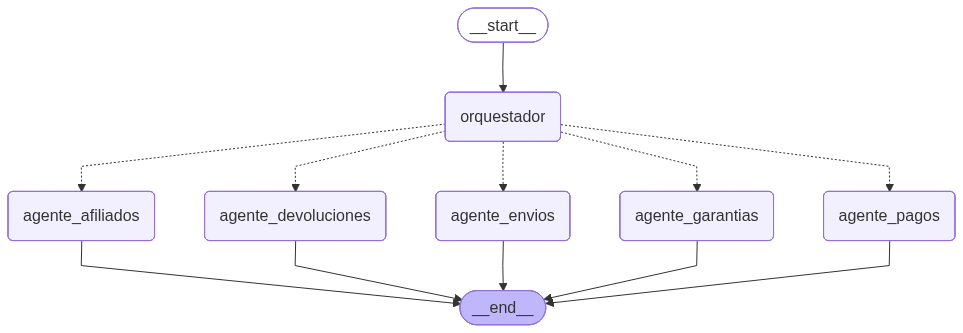

¡Grafo PNG generado y exhibido con éxito!

--- Tratando de Generar el PNG del Grafo vía Mermaid (Requiere Playwright!) ---


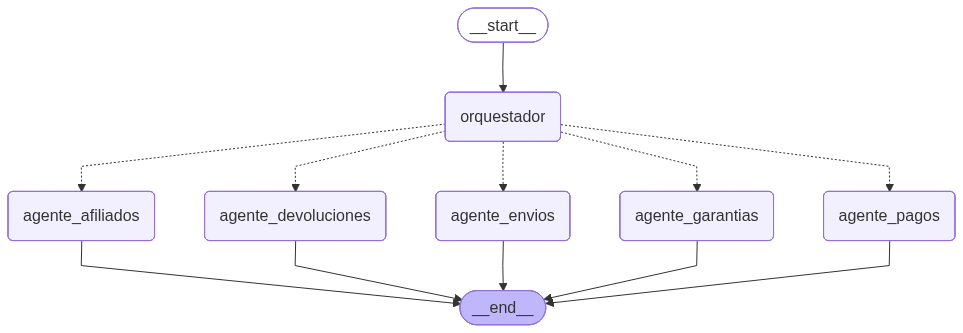

¡Grafo PNG generado y exhibido con éxito!


In [39]:
from IPython.display import Image, display, Markdown
import os

print("\n--- Tratando de Generar el PNG del Grafo vía Mermaid (Requiere Playwright!) ---")
try:
    image_data = graph.get_graph().draw_mermaid_png()
    display(Image(data=image_data))
    print("¡Grafo PNG generado y exhibido con éxito!")

except Exception as e:
    print(f"\nError al tratar de generar el PNG del grafo: {e}")
    print("Esto posiblemente se debe a que:")
    print("1. El método `.draw_mermaid_png()` no existe en su versión de LangGraph.")
    print("2. Faltan dependencias como 'playwright' o sus drivers no fueron instalados.")
    print("   Trata con: pip install playwright && playwright install")
    print("3. Otro error inesperado al acceder al grafo o renderizar.")

    print("\n--- Tratando generar únicamente el código Mermaid (Fallback) ---")
    try:
        mermaid_code = graph.get_graph().draw_mermaid()
        print("\n--- Código Mermaid Generado (Pégalo en https://mermaid.live/ o utiliza Markdown en un entorno compatible) ---")
        print(mermaid_code)
    
    except Exception as e_mermaid:
        print(f"Error al generar el código Mermaid: {e_mermaid}")
        print("Verifica si `graph.get_graph()` está correcto y es accesible.")

print("\n--- Tratando de Generar el PNG del Grafo vía Mermaid (Requiere Playwright!) ---")
try:
    image_data = graph.get_graph().draw_mermaid_png()
    display(Image(data=image_data))
    print("¡Grafo PNG generado y exhibido con éxito!")

except Exception as e:
    print(f"\nError al tratar de generar el PNG del grafo: {e}")
    print("Esto posiblemente se debe a que:")
    print("1. El método `.draw_mermaid_png()` no existe en su versión de LangGraph.")
    print("2. Faltan dependencias como 'playwright' o sus drivers no fueron instalados.")
    print("   Trata con: pip install playwright && playwright install")
    print("3. Otro error inesperado al acceder al grafo o renderizar.")

    print("\n--- Tratando generar únicamente el código Mermaid (Fallback) ---")
    try:
        mermaid_code = graph.get_graph().draw_mermaid()
        print("\n--- Código Mermaid Generado (Pégalo en https://mermaid.live/ o utiliza Markdown en un entorno compatible) ---")
        print(mermaid_code)
    
    except Exception as e_mermaid:
        print(f"Error al generar el código Mermaid: {e_mermaid}")
        print("Verifica si `graph.get_graph()` está correcto y es accesible.")

##Orquestando MultiAgentes - Gradio

Ya pudimos generar nuestros prompts, nuestros nodos y nuestro grafo. Con GradIO, podemos crear una interfaz gráfica que podemos ejecutar en el servidor local, pero si eventualmente deseamos utilizarla en Internet, también es posible.

La idea es reunir todos los códigos que ya ejecutamos previamente y colocarlos en un archivo de Python. Vamos a llamar a este archivo Backend. Aquí se encuentran todas las importaciones. Filtramos los warnings. Cargamos las variables de ambiente y almacenamos las claves de API en variables para traerlas directamente a nuestra ejecución, a nuestro runtime.

##Configurando el entorno y definiendo clases

Vamos a importar las bibliotecas necesarias y configurar nuestro entorno:

In [70]:
# backend.py

import os
import sqlite3
from dotenv import load_dotenv
from typing import TypedDict, List
from langchain_google_genai import ChatGoogleGenerativeAI
from langgraph.graph import StateGraph, END
from langgraph.checkpoint.sqlite import SqliteSaver
import warnings
warnings.filterwarnings("ignore", message=".*TqdmWarning.*")

# Carga las variables de entorno desde el archivo .env
load_dotenv()

# Define las variables de entorno
GEMINI_API_KEY = os.getenv("GEMINI_API_KEY")

Después, definimos nuestra clase AgentState. Establecemos nuestra conexión con los checkpoints. Todo el tiempo hemos tenido nuestra base de datos Checkpoints. Creamos nuestra memoria con el SQL Lite Saver en la conexión.

In [71]:
# Define el estado del agente (AgentState)

class AgentState(TypedDict):
    user_question: str
    category: str
    agent_selected: str
    response: str
    messages: List[str]

# Inicializa la base de datos para checkpoints
conn = sqlite3.connect("checkpoints.db", check_same_thread=False)
memory = SqliteSaver(conn)

##Inicializando el modelo de lenguaje y definiendo prompts

En el modelo, lo inicializamos y en la variable Google API Key, almacenamos nuestra Gemini API Key. Traemos todos los prompts. Definimos nuestros nodos tal como lo hicimos previamente. Simplemente trasladamos el código que teníamos en nuestro notebook a este archivo de Python(backend)

In [43]:
# Inicializa el modelo de lenguaje
model = ChatGoogleGenerativeAI(
    model="gemini-2.5-flash",
    temperature=0
)

# Prompts
triage_prompt = """
Eres un agente orquestador de atención al cliente.

Tu función es analizar la consulta del usuario y decidir qué agente especializado debe atenderla.

No debes responder directamente la consulta.
Solo debes identificar el agente correspondiente.

Agentes disponibles:

- agente_envios
- agente_garantias
- agente_devoluciones
- agente_pagos
- agente_afiliados

Devuelve únicamente uno de estos valores:

agente_envios
agente_garantias
agente_devoluciones
agente_pagos
agente_afiliados

No agregues explicaciones, puntuación ni texto adicional.
"""


prompt_agente_envios = """
Eres un especialista en tiempos, costos y modalidades de envío.

Responde únicamente preguntas relacionadas con envíos.

Si la consulta no pertenece a este tema, indica que debe ser atendida por otro agente.
"""

prompt_agente_garantias = """
Eres un especialista en garantías de productos.

Responde consultas sobre cobertura, plazos, condiciones y procedimientos de garantía.
"""

prompt_agente_devoluciones = """
Eres un especialista en políticas de reembolsos y devoluciones.

Explica claramente los requisitos, plazos y procedimientos.
"""

prompt_agente_pagos = """
Eres un especialista en métodos de pago.

Responde preguntas sobre medios de pago aceptados, cuotas, promociones y validaciones.
"""

prompt_agente_afiliados = """
Eres un especialista en el programa de afiliados.

Explica beneficios, requisitos de inscripción y funcionamiento del programa.
"""

##Construyendo el grafo y definiendo nodos

Por último, construimos el grafo. Aquí está el grafo y un ejemplo de uso del mismo. Para simplificar, llevamos todo a un archivo Python llamado app.py e importamos GradIO. Antes de continuar, creamos un nuevo terminal que será directamente un prompt de comando. No utilizamos PowerShell. En este caso, si GradIO no está en nuestro ambiente, realizamos el pip install de GradIO. 

In [33]:
%pip install -qU gradio

Note: you may need to restart the kernel to use updated packages.


In [45]:
# Construcción del grafo
builder = StateGraph(AgentState)

builder.add_node("orquestador", nodo_orquestador)

builder.add_node("agente_envios", nodo_agente_envios)
builder.add_node("agente_garantias", nodo_agente_garantias)
builder.add_node("agente_devoluciones", nodo_agente_devoluciones)
builder.add_node("agente_pagos", nodo_agente_pagos)
builder.add_node("agente_afiliados", nodo_agente_afiliados)

builder.set_entry_point("orquestador")


# Arista Condicional
builder.add_conditional_edges(
    "orquestador",
    seleccionar_agente,
    {
        "agente_envios": "agente_envios",
        "agente_garantias": "agente_garantias",
        "agente_devoluciones": "agente_devoluciones",
        "agente_pagos": "agente_pagos",
        "agente_afiliados": "agente_afiliados",
    },
)

# Arista Secuencial
builder.add_edge("agente_envios", END)
builder.add_edge("agente_garantias", END)
builder.add_edge("agente_devoluciones", END)
builder.add_edge("agente_pagos", END)
builder.add_edge("agente_afiliados", END)

graph = builder.compile(checkpointer=memory)

##Creando la función y la interfaz Gradio

In [72]:

# Función que ejecuta el grafo
# (Será utilizada posteriormente por Gradio)

import uuid

def responder_consulta(pregunta: str):

    # Crea un identificador único para la conversación
    thread_id = str(uuid.uuid4())

    thread_config = {
        "configurable": {
            "thread_id": thread_id
        }
    }

    # Estado inicial del grafo
    initial_state = {
        "user_question": pregunta,
        "category": "",
        "agent_selected": "",
        "response": "",
        "messages": []
    }

    respuesta = ""

    # Ejecuta el grafo
    for s in graph.stream(initial_state, thread_config):

        paso = list(s.values())[0]

        # Obtiene la respuesta del agente
        if "response" in paso:
            respuesta = paso["response"]

    return respuesta

##Configurando la interfaz Gradio y ejecutando la aplicación

In [78]:
# ==========================================
# app.py
# Interfaz gráfica con Gradio
# ==========================================

import gradio as gr
import uuid

# Importa el grafo construido en backend.py
from backend import graph


# ==========================================
# Función que ejecuta el multiagente
# ==========================================

def responder_consulta(pregunta):

    try:

        # Crea un identificador único para cada conversación
        thread_id = str(uuid.uuid4())

        thread_config = {
            "configurable": {
                "thread_id": thread_id
            }
        }

        # Estado inicial del grafo
        initial_state = {
            "user_question": pregunta,
            "category": "",
            "agent_selected": "",
            "response": "",
            "messages": []
        }

        respuesta = ""

        # Ejecuta el grafo paso a paso
        for s in graph.stream(initial_state, thread_config):

            step = list(s.values())[0]

            # Obtiene la respuesta del agente
            if "response" in step:
                respuesta = step["response"]

        return respuesta

    except Exception as e:

        # Muestra el error completo en la terminal
        print(f"Error: {e}")

        # Devuelve un mensaje amigable en Gradio
        return (
            "❌ Ocurrió un error al procesar la consulta.\n\n"
            f"Detalle técnico: {e}"
        )

# ==========================================
# Construcción de la interfaz gráfica
# ==========================================

with gr.Blocks(
    theme=gr.themes.Soft(
        primary_hue="blue",
        secondary_hue="slate",
        neutral_hue="slate",
        spacing_size="sm",
        text_size="sm"
    ),
    title="BimBam Buy AI"
) as demo:

    # Título
    gr.Markdown("""
# 🤖 BimBam Buy AI

### Asistente Inteligente de Atención al Cliente
""")

    # Descripción
    gr.Markdown("""
Bienvenido al asistente inteligente de **BimBam Buy**.

Puedes realizar consultas sobre:

📦 Envíos

🛡️ Garantías

💰 Reembolsos y devoluciones

💳 Métodos de pago

⭐ Programa de afiliados
""")

    gr.Markdown("---")

    with gr.Row():

        # Caja donde escribe el usuario
        pregunta = gr.Textbox(
            label="Escribe tu consulta",
            placeholder="Ej.: ¿Cuánto demora un envío a Córdoba?",
            lines=2,
            autofocus=True
        )

        # Botón
        boton = gr.Button(
            "💬 Consultar",
            variant="primary",
            size="lg"
        )

    # Información sobre el asistente
    gr.Markdown(
        "📚 **Las respuestas se generan utilizando Inteligencia Artificial y la documentación oficial de BimBam Buy almacenada en la base de conocimiento.**"
    )


    # Caja donde aparece la respuesta
    respuesta = gr.Textbox(
        label="Respuesta del asistente",
        lines=12,
)   

    # Asociación del botón con la función
    boton.click(
        fn=responder_consulta,
        inputs=pregunta,
        outputs=respuesta
    )


# ==========================================
# Ejecutar la aplicación
# ==========================================

if __name__ == "__main__":
    demo.launch(share=False, prevent_thread_lock=True)

FAISS de envíos cargado correctamente
FAISS de garantías cargado correctamente
FAISS de devoluciones cargado correctamente
FAISS de pagos cargado correctamente
FAISS de afiliados cargado correctamente


C:\Users\Elida\AppData\Local\Temp\ipykernel_22028\276416418.py:67: UserWarning: The parameters have been moved from the Blocks constructor to the launch() method in Gradio 6.0: theme. Please pass these parameters to launch() instead.
  with gr.Blocks(


* Running on local URL:  http://127.0.0.1:7860
* To create a public link, set `share=True` in `launch()`.
